In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage, AIMessage,BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv


In [3]:
load_dotenv()

True

In [4]:
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [5]:
# define state
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
# define hitl function

def chat_node(state:ChatState):

    decision = interrupt({
        "type" : "approval",
        "reason" :"Model is about to answer a user question.",
        "question" : state["messages"][-1].content,
        "instructions" : "Approve this question? Yes/No"
    })

    if decision["approved"] == 'no':
        return{"messages": [AIMessage(content=("Not approved"))]}    

    else:
        response = llm.invoke(state['messages'])   
        return{"messages": [response]}     
    

In [7]:
# build graph
graph = StateGraph(ChatState)

graph.add_node("chat", chat_node)

graph.add_edge(START, "chat")
graph.add_edge("chat", END)

checkpointer = MemorySaver()

app = graph.compile(checkpointer=checkpointer)


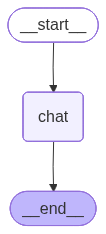

In [8]:
app

In [9]:
# thread id
config = {"configurable":{"thread_id":'1234'}}

initial_input = {
    "messages":[("user", "Explain neural network in a 5 lines.")]
}

result = app.invoke(initial_input, config=config)

In [10]:
result

{'messages': [HumanMessage(content='Explain neural network in a 5 lines.', additional_kwargs={}, response_metadata={}, id='a36ff0b6-d068-4c0e-ae31-2dec6c20a6c8')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain neural network in a 5 lines.', 'instructions': 'Approve this question? Yes/No'}, id='9614d95112750342ce19feda3a444c26')]}

In [11]:
message = result['__interrupt__'][0].value

In [12]:
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain neural network in a 5 lines.',
 'instructions': 'Approve this question? Yes/No'}

In [13]:
user_input = input(f"\nBackend Message - {message} \n Approve this query? (y/n):")

In [14]:
# Resume the graph with the approval decision

final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config = config,
)

In [22]:
print(final_result['messages'][-1].content)

A neural network is a computational model inspired by the human brain.
It consists of interconnected "neurons" organized in layers, processing input data.
Each connection has a "weight" and "bias" that modify the signal's strength.
Through training, the network adjusts these weights and biases by learning from errors.
This enables it to recognize patterns, make predictions, or classify information.
